In [9]:
import os
os.environ['KAGGLE_USERNAME'] = "anastasiakhromova"
os.environ['KAGGLE_KEY'] = "KGAT_a4177bc6807822bc6d28ff5e23b1caff"
#!kaggle datasets download benjaminawd/new-york-times-articles-comments-2020

In [3]:
import pandas as pd 
import numpy as np 

# EDA

In [4]:
data_path = "D:\Projects\\finding_similar_items\data\\new-york-times-articles-comments-2020"

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\Mi\AppData\Local\Temp\ipykernel_13844\2168738046.py:1: SyntaxWarning: invalid escape sequence '\P'
  data_path = "D:\Projects\\finding_similar_items\data\\new-york-times-articles-comments-2020"


In [5]:
test = pd.read_csv(data_path+'\\test.csv')
test

,newsdesk,section,subsection,material,headline,abstract,keywords,word_count,pub_date,is_popular,uniqueID
0,OpEd,Opinion,NaN,Op-Ed,Anyone Else Want to See Trump ‘Shut Up’?,Our president as a terrible toddler.,"['Presidential Election of 2020', 'Biden, Jose...",925,2020-10-01 00:05:51+00:00,1,nyt://article/e467c2ae-2df3-5836-a6ca-b23d0d33...
1,OpEd,Opinion,NaN,Op-Ed,Trump Calls on Extremists to ‘Stand By’,"Instead of condemning violent groups, the pres...","['Presidential Election of 2020', 'United Stat...",902,2020-10-01 00:43:28+00:00,1,nyt://article/9a7ef9e0-1334-56b2-a7f1-288c4887...
2,OpEd,Opinion,NaN,Op-Ed,"Can Mike Espy Make History, Again?",If the Democratic Party claims to value Black ...,"['Black People', 'Blacks', 'Presidential Elect...",1412,2020-10-01 00:45:17+00:00,1,nyt://article/4bb2b763-0088-5e10-b204-19e404f7...
3,Games,Crosswords & Games,NaN,News,In Which Rikishi Wear Mawashi,Adam Fromm is on the line.,['Crossword Puzzles'],849,2020-10-01 02:00:05+00:00,1,nyt://article/0d96205f-edb8-5f1f-8c44-1ddf6ed5...
4,Sports,Sports,Pro Football,News,N.F.L. Week 4 Predictions: Our Picks Against t...,Tom Brady and the Buccaneers are building mome...,"['Football', 'New England Patriots', 'Kansas C...",2690,2020-10-01 04:01:16+00:00,0,nyt://article/afc8295b-3c22-5a5f-9539-3f77b7b8...
...,...,...,...,...,...,...,...,...,...,...,...
3990,Editorial,Opinion,NaN,Op-Ed,What It Takes to Heal From Covid-19,"Survivors can get better, but they need help.","['Chronic Condition (Health)', 'Coronavirus (2...",1002,2020-12-31 15:27:47+00:00,1,nyt://article/e8adbb75-a8b3-5a8c-886b-b9c1195f...
3991,Sports,Sports,Baseball,News,Padres Jolt M.L.B. With Bold Moves to Set Up W...,While many teams continued to assess the finan...,"['San Diego Padres', 'Major League Baseball', ...",1100,2020-12-31 15:47:44+00:00,0,nyt://article/1f11417d-2c57-51b9-b75d-8f67f0a9...
3992,Business,Business Day,NaN,News,"Their Finances Ravaged, Customers Fear Banks W...",Banks have the power to decide whether to let ...,"['Banking and Financial Institutions', 'Corona...",1429,2020-12-31 16:21:40+00:00,1,nyt://article/c4b9edab-bdde-5d81-b496-06fedb52...
3993,Dining,Food,"Wine, Beer & Cocktails",News,Should Wine Be Among Your Health Resolutions?,The new category of ‘clean wines’ is an effort...,"['Wines', 'Grapes', 'Diet and Nutrition', 'Dia...",1307,2020-12-31 17:28:11+00:00,1,nyt://article/efcaf652-ffad-5b4e-9f17-4fd9aff5...


In [6]:
df_main = pd.read_csv('D:\Projects\\finding_similar_items\data\\new-york-times-articles-comments-2020\\nyt-articles-2020.csv')

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\Mi\AppData\Local\Temp\ipykernel_13844\3702147964.py:1: SyntaxWarning: invalid escape sequence '\P'
  df_main = pd.read_csv('D:\Projects\\finding_similar_items\data\\new-york-times-articles-comments-2020\\nyt-articles-2020.csv')


In [7]:
abstract = df_main[['abstract']]

In [15]:
for a in abstract.abstract[:5]:
    print(a)

Congress could do much more to protect Americans who have served their country from predatory for-profit colleges.
Christina Iverson and Jeff Chen ring in the New Year.
All year long, Earth passes through streams of cosmic debris. Here’s a list of major meteor showers and how to spot one.
Never miss an eclipse, a meteor shower, a rocket launch or any other astronomical and space event that's out of this world.
A year full of highs and lows in space just ended, and the 12 months to come  will be full of new highlights in orbit and beyond.


## Tokenization

In [20]:
#!pip install spacy 
import spacy 

In [17]:
#!pip install nltk 

In [18]:
#import sys
#!{sys.executable} -m pip install spacy
#!{sys.executable} -m spacy download en_core_web_sm

In [21]:
nlp = spacy.load("en_core_web_sm")

In [22]:
abstract1 = abstract.abstract.iloc[0]
abstract1

'Congress could do much more to protect Americans who have served their country from predatory for-profit colleges.'

In [23]:
with open("data\stopwords.txt", "r", encoding="utf-8") as f:
    stopwords = set(line.strip() for line in f)

print(stopwords)

{'him', 'because', 'up', 'have', 'into', 'with', 'you', 'than', 'these', 'in', 'not', 'now', 'so', 'before', 'his', 'own', 'himself', 'each', 'further', 'being', 'of', 'them', 'while', 'has', 'ours', 'other', 'most', 'no', 'those', 'we', 'some', 'theirs', 'after', 'this', 'doing', 'and', 'which', 'once', 'the', 'our', 'what', 'she', 'it', 'below', 'from', 'themselves', 'ourselves', 'again', 'did', 'but', 'as', 'how', 'at', 'about', 'all', 'very', 'out', 'nor', 'he', 'having', 'that', 'had', 'are', 's', 'will', 'under', 'be', 'few', 'who', 'against', 'were', 'an', 'am', 'yourselves', 'more', 'my', 'hers', 'during', 'to', 'itself', 'why', 'until', 'your', 'is', 'been', 'such', 'yourself', 'their', 'for', 'her', 'can', 'above', 'herself', 'by', 'yours', 'just', 'its', 'when', 'i', 'both', 'then', 'whom', 'was', 'where', 'there', 'myself', 'a', 'any', 'off', 'they', 'only', 'if', 'over', 'does', 'same', 'too', 'here', 'don', 'me', 'should', 't', 'between', 'on', 'do', 'or', 'through', 'dow

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Mi\AppData\Local\Temp\ipykernel_13844\2471722201.py:1: SyntaxWarning: invalid escape sequence '\s'
  with open("data\stopwords.txt", "r", encoding="utf-8") as f:


In [24]:
def preprocessing(document):
    
    try: 
        word_set = set()
        document = nlp(document)
        for word in document:
            lemma = word.lemma_.strip().lower()
        
            if (
                lemma
                and lemma not in stopwords
                and word.is_alpha
                and not word.is_punct
                and not word.is_space
            ):
                word_set.add(lemma)
        return word_set
    except:
        return set() 

       

In [25]:
#abstract_reshape = preprocessing()

abstract["processed"] = abstract.abstract.apply(preprocessing)

C:\Users\Mi\AppData\Local\Temp\ipykernel_13844\3746059958.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  abstract["processed"] = abstract.abstract.apply(preprocessing)


In [32]:
abstract.processed[:10]

0    {much, congress, profit, serve, country, preda...
1    {christina, iverson, ring, new, jeff, chen, year}
2    {one, pass, meteor, major, long, spot, shower,...
3    {eclipse, miss, meteor, rocket, space, event, ...
4    {month, low, full, space, end, orbit, beyond, ...
5    {much, deploy, support, embassy, make, attack,...
6    {son, want, moola, end, brother, law, make, su...
7    {body, answer, would, woman, find, heart, left...
8    {juicy, eat, herb, leaf, tangy, joy, fill, sea...
9    {like, shariatmadari, word, quirk, snobbery, e...
Name: processed, dtype: object

<Axes: >

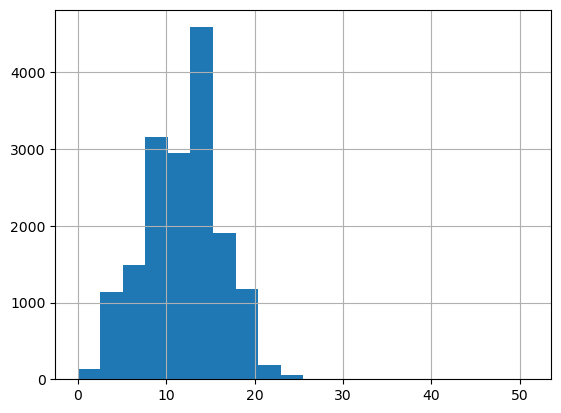

In [30]:
abstract.processed.apply(len).hist(bins=20)

Jaccard similarity

In [14]:
def jaccard (words1:set, words2:set):
    intersection = words1.intersection(words2)
    union = words1.union(words2) 

    if len(union) == 0:
        jaccard_sim = 0
    else:
        jaccard_sim = round(len(intersection) /len(union), 5)
    return jaccard_sim

words1 = abstract.processed.iloc[10]
words2 = abstract.processed.iloc[10532]
jacsim1 = jaccard(words1, words2)

In [26]:
jacsim1

0.14286

In [27]:
type(abstract)

pandas.core.frame.DataFrame

In [16]:
def jaccard_sim_for_main (df:pd.DataFrame, number_main:int, top_k=5):
    main_abstract = df.processed.iloc[number_main]
    overall_jaccard_for_main = dict()
    for idxr, abstract in enumerate(df.processed):
        jacc_sim = jaccard(main_abstract, abstract)
        overall_jaccard_for_main[idxr] = jacc_sim

    overall_jaccard_for_main = sorted(
    overall_jaccard_for_main.items(),
    key=lambda x: x[1],
    reverse=True
    )[:top_k]
    return overall_jaccard_for_main
        

In [17]:
jaccard_sim_for_1 = jaccard_sim_for_main(abstract, 10)
jaccard_sim_for_1

[(0, 0), (1, 0), (2, 0), (3, 0), (4, 0)]

In [53]:
def jaccard_total(df:pd.DataFrame, threshold = 0.2):
    jaccard_final = {}
    for article_idx, article in enumerate(df.processed):
        jaccard_sim_idx = jaccard_sim_for_main(df, article_idx, top_k=len(df))
        for pairs in jaccard_sim_idx:
            if (pairs[1] > threshold) and (pairs[0] > article_idx):
                jaccard_final[(article_idx, pairs[0])] = pairs[1]

    total_jaccard = sorted(
    jaccard_final.items(),
    key=lambda x: x[1],
    reverse=True
    )
    return total_jaccard

In [54]:
len(abstract)

16787

In [55]:
jaccard_total_d = jaccard_total(abstract)

In [56]:
jaccard_total_d

[((58, 3015), 1.0),
 ((58, 4533), 1.0),
 ((58, 7804), 1.0),
 ((66, 7810), 1.0),
 ((143, 468), 1.0),
 ((143, 812), 1.0),
 ((143, 1114), 1.0),
 ((143, 1465), 1.0),
 ((143, 1792), 1.0),
 ((143, 2139), 1.0),
 ((143, 2424), 1.0),
 ((143, 2759), 1.0),
 ((143, 3102), 1.0),
 ((143, 3447), 1.0),
 ((143, 3840), 1.0),
 ((143, 6148), 1.0),
 ((143, 7272), 1.0),
 ((143, 7875), 1.0),
 ((143, 8186), 1.0),
 ((143, 8474), 1.0),
 ((143, 9335), 1.0),
 ((143, 10842), 1.0),
 ((143, 11151), 1.0),
 ((143, 12298), 1.0),
 ((143, 13204), 1.0),
 ((143, 13537), 1.0),
 ((143, 16339), 1.0),
 ((153, 479), 1.0),
 ((153, 1133), 1.0),
 ((153, 1472), 1.0),
 ((153, 1801), 1.0),
 ((153, 2431), 1.0),
 ((153, 2770), 1.0),
 ((153, 3108), 1.0),
 ((153, 3456), 1.0),
 ((153, 3849), 1.0),
 ((153, 4249), 1.0),
 ((153, 4656), 1.0),
 ((153, 5025), 1.0),
 ((153, 5391), 1.0),
 ((153, 5778), 1.0),
 ((153, 6160), 1.0),
 ((153, 6534), 1.0),
 ((153, 6916), 1.0),
 ((153, 11992), 1.0),
 ((153, 12310), 1.0),
 ((153, 12617), 1.0),
 ((153, 129

In [ ]:
print(abstract.abstract.iloc[552])
print(abstract.abstract.iloc[565])

Senator Booker interviews for The New York Times’s endorsement.
Senator Warren interviews for The New York Times’s endorsement.


MinHash

In [74]:
from datasketch import MinHash, MinHashLSH

In [78]:
def create_minhash(tokens, num_permitations=128):
    minhash = MinHash(num_perm=num_permitations, seed=7)
    for token in tokens:
        minhash.update(token.encode('utf8'))
    return minhash
    

In [79]:
def generate_minhashs(tokens_list):
    minhashs = {}
    for idx, tokens in enumerate(tokens_list):
        minhash_t = create_minhash(tokens)
        minhashs[idx] = minhash_t
    return minhashs

In [80]:
minhashs_list = generate_minhashs(abstract.processed)

In [82]:
minhashs_list[0].hashvalues

array([ 707749404,  347028220,  400058551,   43546765,  505129740,
         15608448,  627940067,  128669491,  289958203,  774278953,
        152749646, 1166465831,  373291504,  389376052,  711524712,
         91162290,   75188705,   99206128,  243382014,  574589508,
        165060821,  480936439,   70625004, 1311977962,  611409358,
        459536849,  297682872,  147104448,  261698346,  315374390,
        372653730,    8865041,  494367057,  292406418,  577674347,
        480146619,  470874541,  643573593,   53452095,    7994244,
         77760892,   59969147,   18083807, 1018128814,  133494663,
        117388653,  229115136,  492263217,   99627946,  664683497,
        700143525,  441361013,  117021468,  418212819,  313193937,
        984593224,  136077265,    1841052,  183609486,  205513169,
         47339689,  291663679,  271958937,  312033872,  183772422,
       1222222728,  432939470,   88571120,   62543956,  490202235,
        755905331,  167218994,  332961802,  133777597,  436702

In [88]:
def minhash_sim_for_main (minhash_list, number_main:int, top_k=5):
    main_minhash = minhash_list[number_main]
    overall_minhash_for_main = dict()
    for idxr, minhash in enumerate(minhash_list):
        print(main_minhash)
        print(minhash)
        print(idxr)
        minhash_sim = main_minhash.jaccard(minhash)
        overall_minhash_for_main[idxr] = minhash_sim

    overall_minhash_for_main = sorted(
    overall_minhash_for_main.items(),
    key=lambda x: x[1],
    reverse=True
    )[:top_k]
    return overall_minhash_for_main
        

In [98]:
def minhash_sim_for_main (minhash_list, number_main:int, top_k=5):
    main_minhash = minhash_list[number_main]
    overall_minhash_for_main = dict()
    for i in range(len(minhash_list)):
        if i == number_main:
            continue
        minhash = minhash_list[i]
        minhash_sim = main_minhash.jaccard(minhash)
        overall_minhash_for_main[i] = minhash_sim

    overall_minhash_for_main = sorted(
    overall_minhash_for_main.items(),
    key=lambda x: x[1],
    reverse=True
    )[:top_k]
    return overall_minhash_for_main
        

Checking minhash similarity for random articles

In [99]:
minhash_check = minhash_sim_for_main(minhashs_list, 10)

In [100]:
minhash_check

[(2952, 0.203125),
 (2526, 0.1328125),
 (10532, 0.1328125),
 (12416, 0.1171875),
 (2988, 0.109375)]

In [97]:
abstract.processed.iloc[[10, 2952, 2526]].values

array([{'eat', 'step', 'intermittent', 'less', 'try', 'fasting', 'drink', 'oyster', 'alcohol'},
       {'balanced', 'designer', 'intermittent', 'yam', 'proponent', 'fasting', 'soup', 'rely', 'bright', 'drink', 'stay', 'herbal', 'simple'},
       {'try', 'easy'}], dtype=object)

Results are correct. 

The next step is creating pairs of comparison between each article's minhash and every other minhash.

In [106]:
from tqdm import tqdm

In [104]:
!pip install tqdm

In [107]:
def minhash_total(minhash_list, threshold = 0.2):
    minhash_final = {}
    for i in tqdm(range(len(minhash_list))):
        minhash_sim_idx = minhash_sim_for_main(minhash_list, i, top_k=len(minhash_list))
        for pairs in minhash_sim_idx:
            if (pairs[1] > threshold) and (pairs[1] < 1) and (pairs[0] > i):
                minhash_final[(i, pairs[0])] = pairs[1]

    total_minhash = sorted(
    minhash_final.items(),
    key=lambda x: x[1],
    reverse=True
    )
    return total_minhash

In [108]:
minhashtotal_check = minhash_total(minhashs_list)

  0%|          | 0/16787 [00:00<?, ?it/s]

100%|██████████| 16787/16787 [13:02<00:00, 21.45it/s]


In [109]:
minhashtotal_check

[((9248, 9852), 0.9375),
 ((9248, 11075), 0.9375),
 ((9852, 10762), 0.9375),
 ((10762, 11075), 0.9375),
 ((58, 9253), 0.9296875),
 ((3015, 9253), 0.9296875),
 ((4533, 9253), 0.9296875),
 ((7804, 9253), 0.9296875),
 ((5724, 16679), 0.90625),
 ((8144, 8446), 0.90625),
 ((58, 14458), 0.890625),
 ((58, 15947), 0.890625),
 ((3015, 14458), 0.890625),
 ((3015, 15947), 0.890625),
 ((4533, 14458), 0.890625),
 ((4533, 15947), 0.890625),
 ((7804, 14458), 0.890625),
 ((7804, 15947), 0.890625),
 ((8731, 10202), 0.8828125),
 ((8731, 10510), 0.8828125),
 ((8731, 10807), 0.8828125),
 ((9015, 10202), 0.8828125),
 ((9015, 10510), 0.8828125),
 ((9015, 10807), 0.8828125),
 ((9295, 10202), 0.8828125),
 ((9295, 10510), 0.8828125),
 ((9295, 10807), 0.8828125),
 ((9598, 10202), 0.8828125),
 ((9598, 10510), 0.8828125),
 ((9598, 10807), 0.8828125),
 ((9900, 10202), 0.8828125),
 ((9900, 10510), 0.8828125),
 ((9900, 10807), 0.8828125),
 ((387, 12219), 0.875),
 ((726, 12219), 0.875),
 ((1028, 12219), 0.875),
 ((20

In [110]:
lsh = MinHashLSH(threshold=0.3)

for i in range(len(minhashs_list)):
    lsh.insert(i, minhashs_list[i])
    

In [111]:
lsh.query(minhashs_list[10])

[2952, 10]

In [112]:
def lsh_sim_total(minhash_list):
    similar_pairs = []

    for doc_id, minhash in minhash_list.items():
        candidates = lsh.query(minhash)
        
        for candidate_id in candidates:
            if candidate_id != doc_id:
                pair = tuple(sorted([doc_id, candidate_id]))
                similar_pairs.append(pair)

    similar_pairs = set(similar_pairs)
    return similar_pairs

In [113]:
lsh_total = lsh_sim_total(minhashs_list)

In [114]:
lsh_total

{(5383, 5931),
 (11833, 12110),
 (7561, 8525),
 (3660, 16187),
 (190, 3656),
 (12307, 15184),
 (7386, 11153),
 (1257, 14414),
 (4249, 13549),
 (4013, 14770),
 (9858, 12504),
 (2301, 10663),
 (7282, 12493),
 (11944, 13097),
 (6824, 15587),
 (3896, 5325),
 (625, 10939),
 (766, 12110),
 (2865, 7029),
 (816, 1085),
 (9616, 16354),
 (6115, 12646),
 (86, 5935),
 (1521, 5038),
 (9864, 16456),
 (5268, 9741),
 (7782, 8874),
 (1636, 5550),
 (10992, 15816),
 (2804, 4309),
 (4761, 16326),
 (2509, 14749),
 (5037, 13780),
 (5307, 7225),
 (9546, 14080),
 (9195, 13099),
 (196, 3070),
 (1429, 12804),
 (7946, 14351),
 (4474, 11573),
 (6747, 7611),
 (10776, 15410),
 (3042, 9735),
 (4630, 12086),
 (7162, 15932),
 (8339, 16497),
 (4483, 16762),
 (2246, 16217),
 (3430, 11537),
 (5479, 10311),
 (12645, 16468),
 (5193, 7473),
 (8904, 16683),
 (6029, 7745),
 (10597, 14132),
 (4630, 9053),
 (2109, 8749),
 (6474, 16497),
 (5939, 12955),
 (11009, 16520),
 (3444, 4238),
 (6114, 9546),
 (8712, 13480),
 (1444, 16468

TF-IDF

Jaccard similarity doesn't take into account the words' frequency, additionally, it doesn't make any difference between common words among the majority of the articles.

In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [31]:
vectorizer = TfidfVectorizer(max_features=50000, ngram_range=(1,2))

In [41]:
def preprocessing_tfidf(document):
    
    try: 
        word_array = []
        document = nlp(document)
        for word in document:
            lemma = word.lemma_.strip().lower()
        
            if (
                lemma
                and lemma not in stopwords
                and word.is_alpha
                and not word.is_punct
                and not word.is_space
            ):
                word_array.append(lemma)
        return ' '.join(word_array)
    except:
       return '' 

       

In [42]:
abstract["processed_tfidf"] = abstract.abstract.apply(preprocessing_tfidf)

C:\Users\Mi\AppData\Local\Temp\ipykernel_13844\692275665.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  abstract["processed_tfidf"] = abstract.abstract.apply(preprocessing_tfidf)


In [45]:
tf_idf_matrix = vectorizer.fit_transform(abstract.processed_tfidf)

In [47]:
cos_sim = cosine_similarity(tf_idf_matrix)
df_cos_sim = pd.DataFrame(cos_sim)
df_cos_sim

,0,1,2,3,4,5,6,7,8,9,...,16777,16778,16779,16780,16781,16782,16783,16784,16785,16786
0,1.0,0.000000,0.000000,0.000000,0.000000,0.025057,0.00000,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
1,0.0,1.000000,0.022175,0.000000,0.031895,0.000000,0.00000,0.022375,0.0,0.0,...,0.0,0.0,0.000000,0.015198,0.0,0.0,0.000000,0.000000,0.012946,0.000000
2,0.0,0.022175,1.000000,0.303835,0.016421,0.000000,0.00000,0.019051,0.0,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.012914,0.000000,0.000000,0.000000
3,0.0,0.000000,0.303835,1.000000,0.036162,0.000000,0.00000,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.017386,0.000000,0.000000,0.000000
4,0.0,0.031895,0.016421,0.036162,1.000000,0.000000,0.03377,0.016570,0.0,0.0,...,0.0,0.0,0.000000,0.011255,0.0,0.0,0.000000,0.000000,0.009587,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16782,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.000000,0.0,1.0,0.000000,0.000000,0.000000,0.000000
16783,0.0,0.000000,0.012914,0.017386,0.000000,0.000000,0.00000,0.000000,0.0,0.0,...,0.0,0.0,0.032635,0.000000,0.0,0.0,1.000000,0.000000,0.000000,0.000000
16784,0.0,0.000000,0.000000,0.000000,0.000000,0.022166,0.00000,0.000000,0.0,0.0,...,0.0,0.0,0.015710,0.000000,0.0,0.0,0.000000,1.000000,0.000000,0.180266
16785,0.0,0.012946,0.000000,0.000000,0.009587,0.000000,0.00000,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.011557,0.0,0.0,0.000000,0.000000,1.000000,0.000000


Количество пар: 140,893,291
count    1.408933e+08
mean     3.568597e-03
std      1.360082e-02
min      0.000000e+00
50%      0.000000e+00
90%      1.314681e-02
95%      2.678481e-02
99%      5.676315e-02
99.5%    7.320154e-02
99.9%    1.275874e-01
max      1.000000e+00
dtype: float64


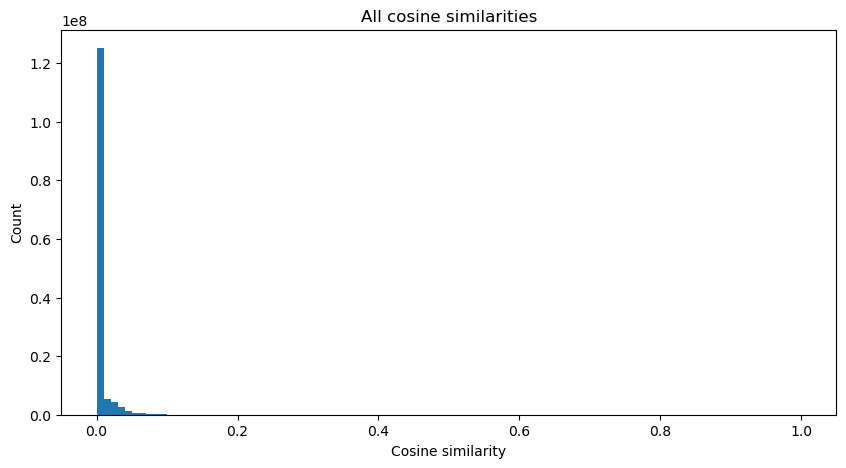

Ненулевых пар: 16,793,354
Доля ненулевых: 11.92%


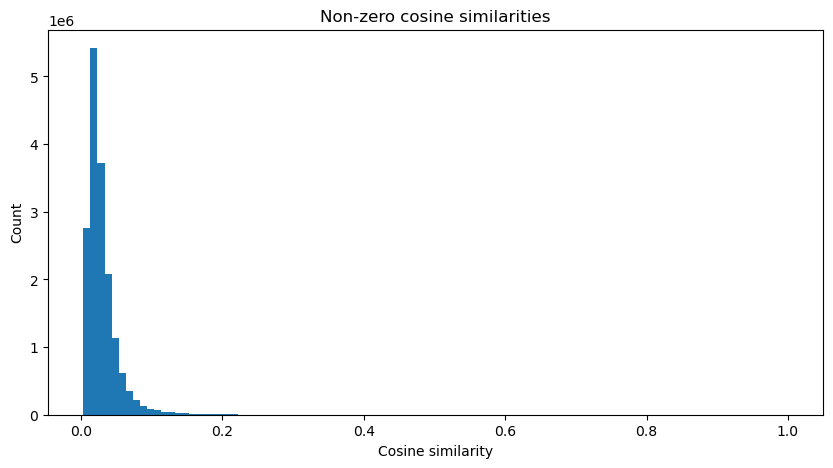

In [48]:
import matplotlib.pyplot as plt

# Верхний треугольник без диагонали
sim_values = cos_sim[np.triu_indices_from(cos_sim, k=1)]

print(f"Количество пар: {len(sim_values):,}")

# Квантили
print(
    pd.Series(sim_values).describe(
        percentiles=[0.9, 0.95, 0.99, 0.995, 0.999]
    )
)

# Гистограмма всех similarity
plt.figure(figsize=(10, 5))
plt.hist(sim_values, bins=100)
plt.xlabel("Cosine similarity")
plt.ylabel("Count")
plt.title("All cosine similarities")
plt.show()

# Только ненулевые similarity
sim_values_nonzero = sim_values[sim_values > 0]

print(f"Ненулевых пар: {len(sim_values_nonzero):,}")
print(f"Доля ненулевых: {len(sim_values_nonzero)/len(sim_values):.2%}")

plt.figure(figsize=(10, 5))
plt.hist(sim_values_nonzero, bins=100)
plt.xlabel("Cosine similarity")
plt.ylabel("Count")
plt.title("Non-zero cosine similarities")
plt.show()


In [49]:
pd.Series(cos_sim.flatten()).describe(
    percentiles=[0.9, 0.95, 0.99, 0.995, 0.999]
)

count    2.818034e+08
mean     3.627929e-03
std      1.562333e-02
min      0.000000e+00
50%      0.000000e+00
90%      1.316108e-02
95%      2.680457e-02
99%      5.688801e-02
99.5%    7.352493e-02
99.9%    1.301748e-01
max      1.000000e+00
dtype: float64

In [50]:
threshold = 0.5

rows, cols = np.where(np.triu(cos_sim, k=1) >= threshold)

pairs = pd.DataFrame({
    "doc_1": rows,
    "doc_2": cols,
    "similarity": cos_sim[rows, cols]
}).sort_values("similarity", ascending=False)

pairs.head(20)

,doc_1,doc_2,similarity
3097,5099,6376,1.0
3094,5099,6171,1.0
3053,5040,8123,1.0
3052,5040,8075,1.0
3051,5040,8023,1.0
3050,5040,7966,1.0
3049,5040,7824,1.0
3048,5040,7791,1.0
3047,5040,7611,1.0
3046,5040,7537,1.0


In [52]:
abstract.abstract.iloc[[5099, 6376, 6171]].values

array(['The latest on stock market and business news during the coronavirus outbreak.',
       'The latest on stock market and business news during the coronavirus outbreak.',
       'The latest on stock market and business news during the coronavirus outbreak.'],
      dtype=object)